In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from google.colab import drive

drive.mount('/content/drive')

# Data
excl = pd.read_csv("drive/MyDrive/NLP Final Project/model_results_excluding_2008.csv")
incl = pd.read_csv("drive/MyDrive/NLP Final Project/model_results_including_2008.csv")
excl["Dataset"] = "Excl. 2008"
incl["Dataset"] = "Incl. 2008"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Colour palette
BG      = "#fffcf8"   # page background
PANEL   = "#f5f0e8"   # chart background
BLUE    = "#2563eb"   # Word2Vec
ORANGE  = "#ea580c"   # Bag of Words
GREEN   = "#16a34a"   # Neural / LLM
PURPLE  = "#7c3aed"   # fallback / other
YELLOW  = "#ca8a04"   # VADER
GRID    = "#e0d8cc"   # gridlines
TEXT    = "#1a1a1a"   # primary text
SUBTEXT = "#666666"   # secondary text / baselines

# maps each group name to the models that belong to it
GROUPS = {
    "Baselines":    ["Baseline - Random", "Baseline - Majority",
                     "Baseline - Previous Day Momentum", "Baseline - Momentum"],
    "VADER":        ["VADER + Logistic Regression", "VADER + Random Forest", "VADER + CNN"],
    "Word2Vec":     ["Word2Vec + Logistic Regression", "Word2Vec + Linear SVM",
                     "Word2Vec + KNN", "Word2Vec + Naive Bayes",
                     "Word2Vec + MLP", "Word2Vec + Multi-Layer Perceptron", "Word2Vec + CNN"],
    "Bag of Words": ["Bag of Words + Logistic Regression", "Bag of Words + CNN",
                     "Bag of Words + KNN", "Bag of Words + Naive Bayes",
                     "Bag of Words + Multilayer Perceptron"],
    "Neural / LLM": ["BERT", "Mistral"],
}

# maps each group to its plot colour
GROUP_COLORS = {
    "Baselines":    SUBTEXT,
    "VADER":        YELLOW,
    "Word2Vec":     BLUE,
    "Bag of Words": ORANGE,
    "Neural / LLM": GREEN,
}

def get_group(name):
    """Return the group a model belongs to, or 'Other' if not found."""
    for g, members in GROUPS.items():
        if name in members:
            return g
    return "Other"

# assign group labels to both dataframes
for df in [excl, incl]:
    df["Group"] = df["Model"].apply(get_group)

def styled_ax(ax):
    """Apply consistent dark-on-light styling to a matplotlib axis."""
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=11)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)

#Best F1 per Feature Group

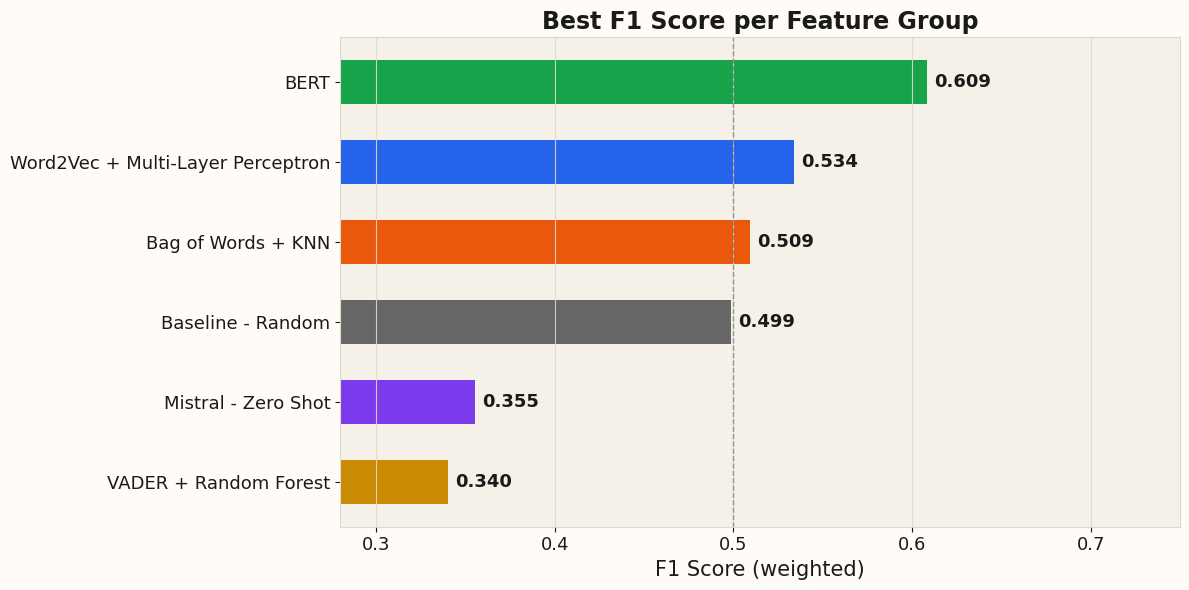

In [ ]:
fig1, axes1 = plt.subplots(1, 1, figsize=(12, 6), facecolor=BG)

ax = axes1
styled_ax(ax)

# keep only the highest F1 model within each group
df_f1 = incl.dropna(subset=["F1_weighted"])
df_f1 = df_f1.loc[df_f1.groupby("Group")["F1_weighted"].idxmax()]
df_f1 = df_f1.sort_values("F1_weighted", ascending=True)

# colour each bar by its feature group
colors = [GROUP_COLORS.get(g, PURPLE) for g in df_f1["Group"]]
bars = ax.barh(df_f1["Model"], df_f1["F1_weighted"],
               color=colors, height=0.55, edgecolor="none")

# annotate each bar with its exact value
for bar, val in zip(bars, df_f1["F1_weighted"]):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color=TEXT, fontsize=13, fontweight="bold")

ax.axvline(0.5, color=SUBTEXT, linestyle="--", linewidth=1, alpha=0.6, label="F1 = 0.5")
ax.set_xlim(0.28, 0.75)
ax.set_xlabel("F1 Score (weighted)", fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.set_title("Best F1 Score per Feature Group", fontsize=17, fontweight="bold", color=TEXT)
ax.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.9)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig("fig_f1_best_per_group.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

#Best Accuracy per Feature Group

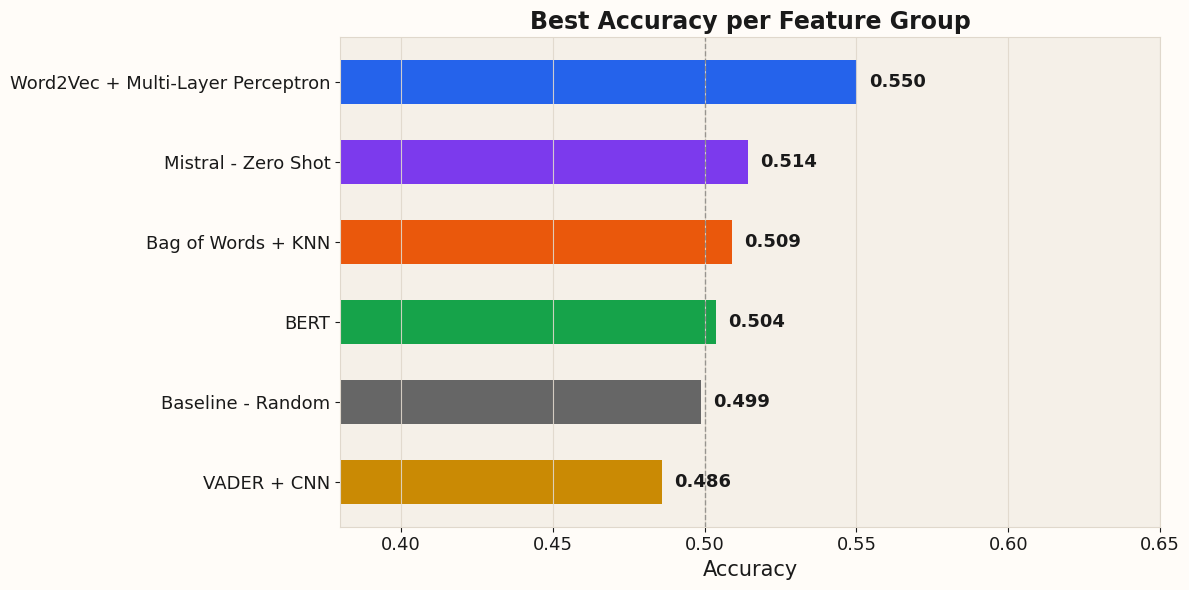

In [5]:
fig1 = plt.figure(figsize=(12, 6), facecolor=BG)

ax = fig1.add_subplot(111)
styled_ax(ax)

# keep only the highest accuracy model within each group
df_acc = incl.dropna(subset=["Accuracy"])
df_acc = df_acc.loc[df_acc.groupby("Group")["Accuracy"].idxmax()]
df_acc = df_acc.sort_values("Accuracy", ascending=True)

# colour each bar by its feature group
colors = [GROUP_COLORS.get(g, PURPLE) for g in df_acc["Group"]]
bars = ax.barh(df_acc["Model"], df_acc["Accuracy"],
               color=colors, height=0.55, edgecolor="none")

# annotate each bar with its exact value
for bar, val in zip(bars, df_acc["Accuracy"]):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color=TEXT, fontsize=13, fontweight="bold")

ax.axvline(0.5, color=SUBTEXT, linestyle="--", linewidth=1, alpha=0.6, label="Accuracy = 0.5")
ax.set_xlim(0.38, 0.65)
ax.set_xlabel("Accuracy", fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.set_title("Best Accuracy per Feature Group", fontsize=17, fontweight="bold", color=TEXT)
ax.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.9)
ax.grid(axis="y", visible=False)


plt.tight_layout()
plt.savefig("fig_accuracy_best_per_group.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

#Average Metrics by Feature Group

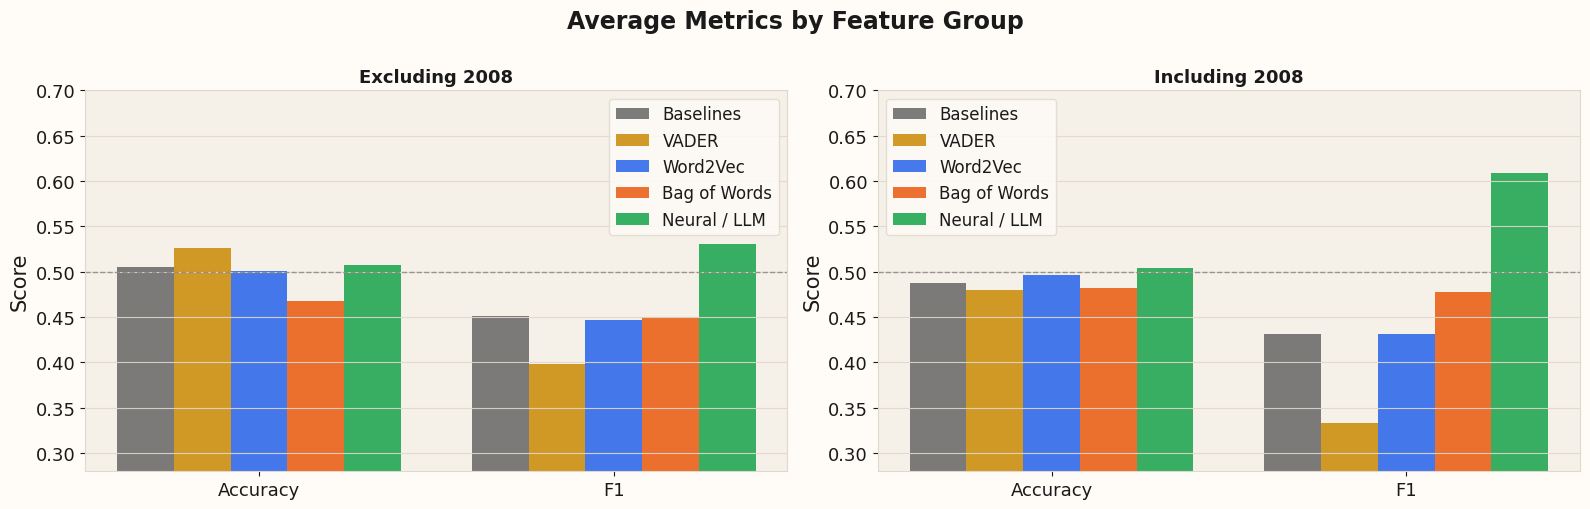

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
fig.suptitle("Average Metrics by Feature Group", color=TEXT, fontsize=17, fontweight="bold", y=1.01)

metrics       = ["Accuracy", "F1_weighted"]
metric_labels = ["Accuracy", "F1"]

for ax, (df, title) in zip(axes, [(excl, "Excluding 2008"), (incl, "Including 2008")]):
    styled_ax(ax)

    # compute mean accuracy and F1 per group, preserving defined group order
    group_means = df.groupby("Group")[metrics].mean().reindex(
        [g for g in GROUPS if g in df["Group"].values])

    x     = np.arange(len(metric_labels))
    n     = len(group_means)
    width = 0.8 / n

    for i, (grp, row) in enumerate(group_means.iterrows()):
        # offset each group's bars so they sit side by side within each metric
        offset = (i - n/2 + 0.5) * width
        color  = GROUP_COLORS.get(grp, PURPLE)
        ax.bar(x + offset, row[metrics].values, width,
               color=color, alpha=0.85, edgecolor="none", label=grp)

    ax.axhline(0.5, color=SUBTEXT, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=14)
    ax.set_ylim(0.28, 0.70)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_ylabel("Score", fontsize=15)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.9)
    ax.grid(axis="x", visible=False)
    ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=TEXT, fontsize=12)

plt.tight_layout()
plt.savefig("fig_avg_metrics_by_group.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

#Model Results by Feature Group

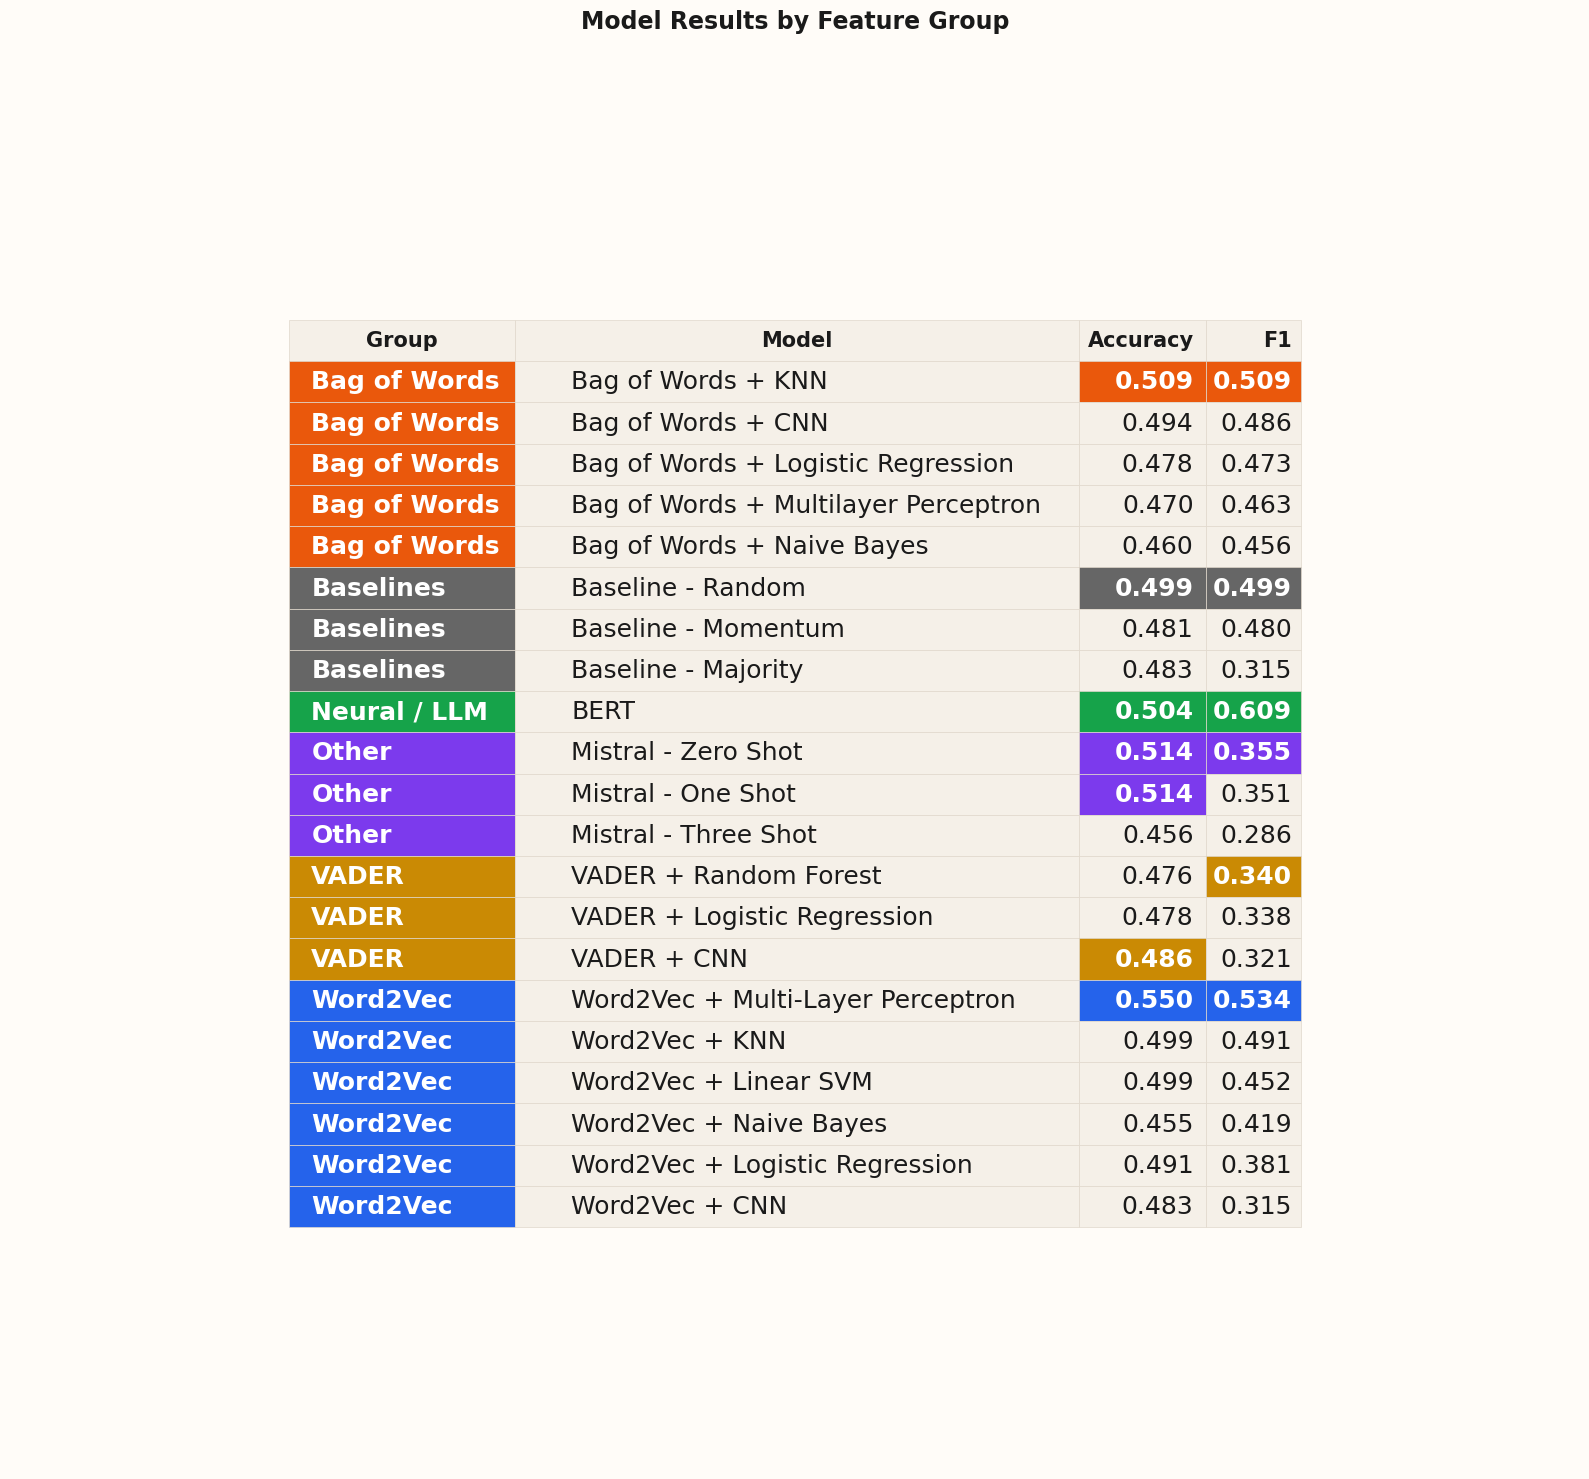

In [ ]:
# build table data from incl, sorted by group then F1
table_df = incl[["Group", "Model", "Accuracy", "F1_weighted"]].copy()
table_df = table_df.sort_values(["Group", "F1_weighted"], ascending=[True, False])
table_df["Accuracy"]    = table_df["Accuracy"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "—")
table_df["F1_weighted"] = table_df["F1_weighted"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "—")
table_df = table_df.rename(columns={"F1_weighted": "F1", "Group": "Group"})

# figure sizing
n_rows = len(table_df)
fig, ax = plt.subplots(figsize=(16, 0.6 * n_rows + 2), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

fig.suptitle("Model Results by Feature Group", color=TEXT,
             fontsize=17, fontweight="bold", y=1.01)

cols  = ["Group", "Model", "Accuracy", "F1"]
table = ax.table(
    cellText=table_df[cols].values,
    colLabels=cols,
    loc="center",
    cellLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(18)
table.scale(1.5, 2.0)

# style each cell
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(GRID)
    cell.set_linewidth(0.5)

    if row == 0:
        # header
        cell.set_facecolor(PANEL)
        cell.set_text_props(color=TEXT, fontweight="bold", fontsize=15)
    else:
        group = table_df.iloc[row - 1]["Group"]
        color = GROUP_COLORS.get(group, PURPLE)

        if col == 0:
            # group column — coloured background
            cell.set_facecolor(color)
            cell.set_text_props(color="white", fontweight="bold")
        elif col in (2, 3):
            # metric columns
            cell.set_facecolor(PANEL)
            cell.set_text_props(color=TEXT)

            # highlight the best value in each group
            metric_key = "Accuracy" if col == 2 else "F1"
            group_rows = table_df[table_df["Group"] == group]
            best_val   = group_rows[metric_key].max()
            if table_df.iloc[row - 1][metric_key] == best_val:
                cell.set_facecolor(color)
                cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor(PANEL)
            cell.set_text_props(color=TEXT)

    # right-align numeric columns
    if col in (2, 3):
        cell.set_text_props(ha="right")

table.auto_set_column_width([0, 1, 2, 3])

plt.tight_layout()
plt.savefig("fig_table.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

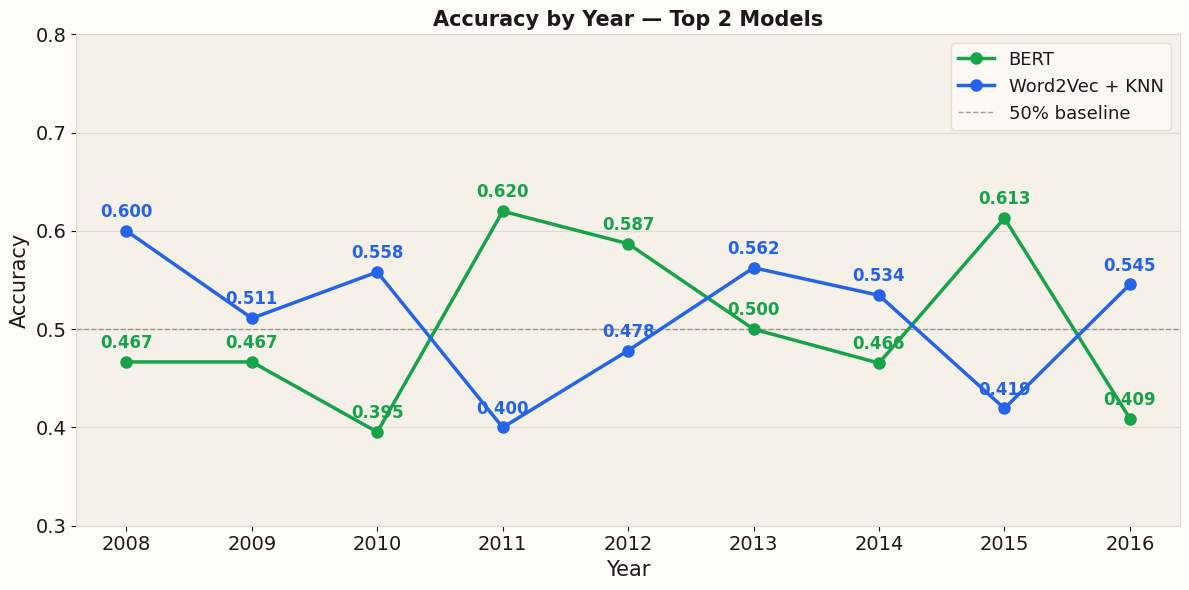

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load yearly results
yearly = pd.read_csv("/content/drive/MyDrive/NLP Final Project/model_results_yearly_including_2008.csv")

# Pick top 2 models
TOP_MODELS = ["BERT", "Word2Vec + KNN"]  # ← swap these for whichever two you want

# Filter and plot
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
styled_ax(ax)

colors = [GREEN, BLUE]

for model, color in zip(TOP_MODELS, colors):
    df_model = yearly[yearly["Model"] == model].sort_values("Year")
    ax.plot(df_model["Year"], df_model["Accuracy"],
            color=color, linewidth=2.5, marker="o",
            markersize=8, label=model, zorder=5)

    # annotate each point with accuracy value
    for _, row in df_model.iterrows():
        ax.annotate(f"{row['Accuracy']:.3f}",
                    (row["Year"], row["Accuracy"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", color=color, fontsize=12, fontweight="bold")

ax.axhline(0.5, color=SUBTEXT, linestyle="--", linewidth=1, alpha=0.6, label="50% baseline")
ax.set_xlabel("Year", fontsize=15)
ax.set_ylabel("Accuracy", fontsize=15)
ax.set_title("Accuracy by Year — Top 2 Models", color=TEXT, fontsize=15, fontweight="bold")
ax.set_xticks(yearly["Year"].unique())
ax.set_ylim(0.3, 0.8)
ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.9)
ax.grid(axis="x", visible=False)
ax.tick_params(axis='both', labelsize=14)
ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=TEXT, fontsize=13)

plt.tight_layout()
plt.savefig("fig_accuracy_by_year.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()